# Collect AI Overview and Gemini responses
Builds a per-ID table with AI Overview snippets (a/b) and Gemini responses (a/b) joined on the shared numeric ID.

In [2]:
from pathlib import Path
import json
import re
import pandas as pd

AIO_ROOT = Path("robust_changes")
GEMINI_PATH = Path("SIGIR_Gemini_small_changes4_resolved.jsonl")

In [3]:
def clean_text(text: str) -> str:
    '''Collapse whitespace so records become single paragraphs.'''
    return " ".join(text.split())


def load_ai_overview_texts(root: Path) -> dict:
    '''Return {id: {'aio_text_a': ..., 'aio_text_b': ...}}.'''
    ai_texts = {}
    pattern = re.compile(r"stratified_benchmark_test_(?P<id>.+?)_(?P<side>[ab])_google_ai_overview\.json")
    for path in root.glob("stratified_benchmark_test_*_google_ai_overview.json"):
        match = pattern.match(path.name)
        if not match:
            continue
        id_ = match.group("id")
        side = match.group("side")
        with path.open() as f:
            payload = json.load(f)
        snippets = [block.get("snippet", "") for block in payload.get("text_blocks", []) if block.get("snippet")]
        ai_texts.setdefault(id_, {})[f"aio_text_{side}"] = clean_text(" ".join(snippets))
    return ai_texts


def load_gemini_texts(path: Path) -> dict:
    '''Return {id: {'gemini_text_a': ..., 'gemini_text_b': ...}}.'''
    gemini_texts = {}
    pattern = re.compile(r"(?P<id>\d+)(?P<side>[ab])$")
    for line in path.read_text().splitlines():
        if not line.strip():
            continue
        record = json.loads(line)
        match = pattern.match(str(record.get("id", "")))
        if not match:
            continue
        id_ = match.group("id")
        side = match.group("side")
        text = clean_text(record.get("text", ""))
        gemini_texts.setdefault(id_, {})[f"gemini_text_{side}"] = text
    return gemini_texts

In [4]:
ai_texts = load_ai_overview_texts(AIO_ROOT)
print(f"AI Overview IDs: {len(ai_texts)}")

if GEMINI_PATH.exists():
    gemini_texts = load_gemini_texts(GEMINI_PATH)
    print(f"Gemini IDs: {len(gemini_texts)}")
else:
    print(f"Gemini file not found: {GEMINI_PATH}")
    gemini_texts = {}

shared_ids = sorted(
    id_
    for id_ in ai_texts.keys() & gemini_texts.keys()
    if {"aio_text_a", "aio_text_b"} <= ai_texts[id_].keys()
    and {"gemini_text_a", "gemini_text_b"} <= gemini_texts[id_].keys()
)

aio_only_a = sorted(id_ for id_, texts in ai_texts.items() if "aio_text_a" in texts and "aio_text_b" not in texts)
aio_only_b = sorted(id_ for id_, texts in ai_texts.items() if "aio_text_b" in texts and "aio_text_a" not in texts)
gemini_only_a = sorted(id_ for id_, texts in gemini_texts.items() if "gemini_text_a" in texts and "gemini_text_b" not in texts)
gemini_only_b = sorted(id_ for id_, texts in gemini_texts.items() if "gemini_text_b" in texts and "gemini_text_a" not in texts)

print(f"AI Overview only-a count: {len(aio_only_a)}, IDs: {aio_only_a}")
print(f"AI Overview only-b count: {len(aio_only_b)}, IDs: {aio_only_b}")
print(f"Gemini only-a count: {len(gemini_only_a)}, IDs: {gemini_only_a}")
print(f"Gemini only-b count: {len(gemini_only_b)}, IDs: {gemini_only_b}")

print(f"Joined IDs with both a/b sides: {len(shared_ids)}")
missing_from_gemini = sorted(ai_texts.keys() - gemini_texts.keys())
missing_from_ai_overview = sorted(gemini_texts.keys() - ai_texts.keys())
print(f"AI-only IDs (not in Gemini): {len(missing_from_gemini)}")
print(missing_from_gemini[:10])
print(f"Gemini-only IDs (not in AI Overview): {len(missing_from_ai_overview)}")
print(missing_from_ai_overview[:10])

records = []
for id_ in shared_ids:
    row = {"ID": id_}
    row.update(ai_texts[id_])
    row.update(gemini_texts[id_])
    records.append(row)

columns = ["ID", "aio_text_a", "aio_text_b", "gemini_text_a", "gemini_text_b"]
df = pd.DataFrame(records, columns=columns)
print(f"DataFrame shape: {df.shape}")
df.head()

AI Overview IDs: 198
Gemini IDs: 200
AI Overview only-a count: 6, IDs: ['1581', '1598', '2390', '4502', '4975', '7327']
AI Overview only-b count: 4, IDs: ['2116', '4419', '5338', '596']
Gemini only-a count: 0, IDs: []
Gemini only-b count: 0, IDs: []
Joined IDs with both a/b sides: 188
AI-only IDs (not in Gemini): 0
[]
Gemini-only IDs (not in AI Overview): 2
['10193', '2449']
DataFrame shape: (188, 5)


,ID,aio_text_a,aio_text_b,gemini_text_a,gemini_text_b
0,10000,Mount St. Helens is an active volcano in south...,Mount St. Helens is an active volcano in the C...,Mount St. Helens is an active stratovolcano lo...,Mount St. Helens is an active stratovolcano lo...
1,10204,"If your iPhone 6 won't turn on, first try a fo...","If your iPhone 6 won't turn on, first try a fo...",It can be frustrating when your iPhone 6 won't...,"If your iPhone 6 won't start, there are severa..."
2,10220,The main European Union (EU) headquarters are ...,"The European Union's main institutions, like t...",The de facto capital and primary headquarters ...,The primary de facto headquarters of the Europ...
3,10268,There are many Marion Counties in the United S...,"There are 17 Marion Counties in the U.S., but ...",Marion County is a common county name in the U...,Marion County is a common county name in the U...
4,10593,"Folsom State Prison is located in Folsom, Cali...","Folsom Prison is located in Folsom, California...","Folsom State Prison is located in Folsom, Cali...","Folsom Prison, officially known as Folsom Stat..."


In [5]:



output_path = Path("combined_ai_overview_gemini.csv")
df.to_csv(output_path, index=False)
print(f"Saved to {output_path}")

Saved to combined_ai_overview_gemini.csv


In [ ]:
GEMINI_API_KEY = ""

# Flexible, supports: 128 - 3072, Recommended: 768, 1536, 3072
OUT_DIMENSIONALITY = 3072

MODEL_ID = "gemini-embedding-001" 

In [7]:
from google import genai
from google.genai import types

client = genai.Client(api_key=GEMINI_API_KEY)




In [8]:
def embed(texts, output_dim=OUT_DIMENSIONALITY):
    res = client.models.embed_content(
        model=MODEL_ID,
        contents=texts,
        config=types.EmbedContentConfig(output_dimensionality=output_dim),
    )
    return res

In [9]:
import ast
import time

if "df" not in globals():
    raise RuntimeError("Run earlier cells to build df before embedding.")

embed_output_path = Path("combined_ai_overview_gemini_embed.csv")


def extract_embedding_values(response):
    """Normalize different response shapes into a flat list of embedding values."""
    if response is None:
        raise ValueError("Empty response")

    def _from_embedding_obj(obj):
        if obj is None:
            return None
        if hasattr(obj, "values"):
            return list(obj.values)
        if hasattr(obj, "embedding") and hasattr(obj.embedding, "values"):
            return list(obj.embedding.values)
        if isinstance(obj, dict):
            if "values" in obj:
                return obj["values"]
            if "embedding" in obj and isinstance(obj["embedding"], dict) and "values" in obj["embedding"]:
                return obj["embedding"]["values"]
        return None

    # try common shapes
    for attr in ("embeddings", "embedding"):
        if hasattr(response, attr):
            candidate = getattr(response, attr)
            if isinstance(candidate, list) and candidate:
                val = _from_embedding_obj(candidate[0])
                if val is not None:
                    return val
            else:
                val = _from_embedding_obj(candidate)
                if val is not None:
                    return val

    # fallback if response is dict-like
    if isinstance(response, dict):
        if "embeddings" in response and response["embeddings"]:
            val = _from_embedding_obj(response["embeddings"][0])
            if val is not None:
                return val
        if "embedding" in response:
            val = _from_embedding_obj(response["embedding"])
            if val is not None:
                return val

    if hasattr(response, "to_dict"):
        try:
            val = extract_embedding_values(response.to_dict())
            if val is not None:
                return val
        except Exception:
            pass

    raise ValueError("Could not parse embedding response; values not found")


def _maybe_list(v):
    if isinstance(v, str):
        try:
            parsed = ast.literal_eval(v)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            return v
    return v




In [10]:

existing_rows = {}
if embed_output_path.exists():
    existing_df = pd.read_csv(embed_output_path)
    existing_rows = {r.ID: r for r in existing_df.itertuples(index=False)}
    print(f"Loaded {len(existing_rows)} existing embeddings from {embed_output_path}")

embed_columns = ["aio_text_a", "aio_text_b", "gemini_text_a", "gemini_text_b"]
embedded_rows = []
failed = []

for row in df.itertuples(index=False):
    row_out = {"ID": row.ID}
    existing = existing_rows.get(row.ID)

    if existing:
        for col in embed_columns:
            val = getattr(existing, col)
            if pd.notna(val):
                row_out[col] = _maybe_list(val)

    for col in embed_columns:
        if col in row_out:
            continue

        text = getattr(row, col)

        def _do_embed():
            resp = embed([text])
            values = extract_embedding_values(resp)
            if len(values) != OUT_DIMENSIONALITY:
                raise ValueError(f"Expected {OUT_DIMENSIONALITY} dims, got {len(values)}")
            return values

        try:
            row_out[col] = _do_embed()
        except Exception as exc:
            print(f"Embed failed for ID {row.ID} {col}; retrying in 3 seconds: {exc}")
            time.sleep(3)
            try:
                row_out[col] = _do_embed()
            except Exception as exc2:
                print(f"\033[91mFailed embedding {col} for ID {row.ID}: {exc2}\033[0m")
                row_out[col] = None
                failed.append((row.ID, col))

    embedded_rows.append(row_out)

embed_df = pd.DataFrame(embedded_rows, columns=["ID", *embed_columns])
missing_counts = {col: embed_df[col].isna().sum() for col in embed_columns}
length_mismatches = {
    col: sum(
        1 for v in embed_df[col]
        if v is not None and (not hasattr(v, "__len__") or len(v) != OUT_DIMENSIONALITY)
    )
    for col in embed_columns
}

print("Missing embeddings per column:", missing_counts)
print("Length mismatches per column:", length_mismatches)
print(f"Total failed embeddings: {len(failed)}")

embed_df.to_csv(embed_output_path, index=False)
print(f"Saved embeddings to {embed_output_path}")

Loaded 188 existing embeddings from combined_ai_overview_gemini_embed.csv
Missing embeddings per column: {'aio_text_a': np.int64(0), 'aio_text_b': np.int64(0), 'gemini_text_a': np.int64(0), 'gemini_text_b': np.int64(0)}
Length mismatches per column: {'aio_text_a': 0, 'aio_text_b': 0, 'gemini_text_a': 0, 'gemini_text_b': 0}
Total failed embeddings: 0
Saved embeddings to combined_ai_overview_gemini_embed.csv


In [13]:
# Inspect embedding dimensionality in the saved embeddings
dims_per_col = {
    col: {len(v) for v in embed_df[col] if isinstance(v, (list, tuple))}
    for col in embed_columns
}
print("Embedding dimensionality per column:", dims_per_col)

overall_dims = set().union(*dims_per_col.values())
print("Unique dimensions across all embedding columns:", overall_dims)
if len(overall_dims) == 1:
    print(f"All embeddings have dimension {next(iter(overall_dims))}")
else:
    print("Mismatch in embedding dimensions detected.")

Embedding dimensionality per column: {'aio_text_a': {3072}, 'aio_text_b': {3072}, 'gemini_text_a': {3072}, 'gemini_text_b': {3072}}
Unique dimensions across all embedding columns: {3072}
All embeddings have dimension 3072


Average cosine similarities:
cos_aio_a_aio_b: 0.9209
cos_aio_a_gemini_a: 0.8833
cos_aio_a_gemini_b: 0.8817
cos_aio_b_gemini_a: 0.8843
cos_aio_b_gemini_b: 0.8827
cos_gemini_a_gemini_b: 0.9456


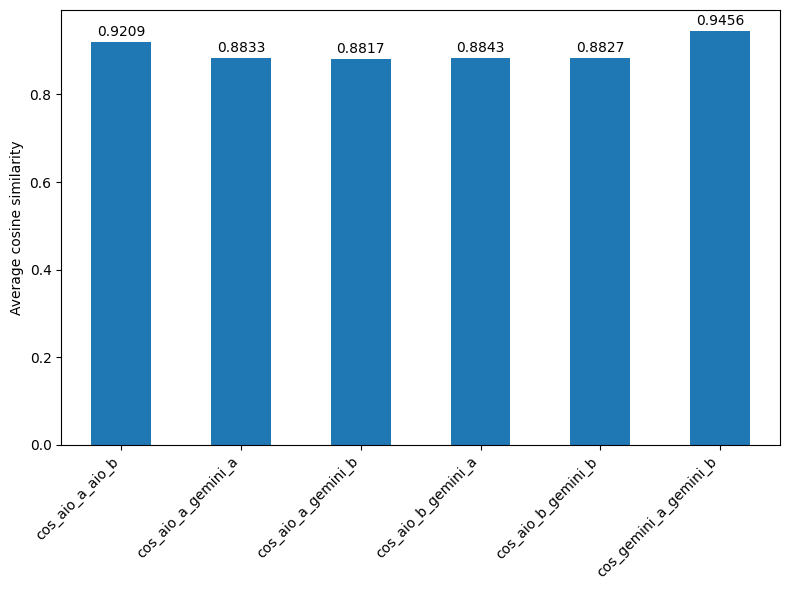

Saved cosine similarities to combined_ai_overview_gemini_embed_cos_sim.csv


In [14]:
import numpy as np
import pandas as pd
from pathlib import Path
import json


embed_columns = ["aio_text_a", "aio_text_b", "gemini_text_a", "gemini_text_b"]
embed_output_path = Path("combined_ai_overview_gemini_embed.csv")

# Load embeddings
embed_df = pd.read_csv(embed_output_path)

# Ensure embedding columns are lists of floats
for col in embed_columns:
    embed_df[col] = embed_df[col].apply(_maybe_list)

def _cosine(u, v):
    if u is None or v is None:
        return np.nan
    u_arr, v_arr = np.array(u, dtype=float), np.array(v, dtype=float)
    if u_arr.shape != v_arr.shape or u_arr.size == 0:
        return np.nan
    denom = np.linalg.norm(u_arr) * np.linalg.norm(v_arr)
    return float(np.dot(u_arr, v_arr) / denom) if denom else np.nan

pairs = {
    "cos_aio_a_aio_b": ("aio_text_a", "aio_text_b"),
    "cos_aio_a_gemini_a": ("aio_text_a", "gemini_text_a"),
    "cos_aio_a_gemini_b": ("aio_text_a", "gemini_text_b"),
    "cos_aio_b_gemini_a": ("aio_text_b", "gemini_text_a"),
    "cos_aio_b_gemini_b": ("aio_text_b", "gemini_text_b"),
    "cos_gemini_a_gemini_b": ("gemini_text_a", "gemini_text_b"),
}

for out_col, (c1, c2) in pairs.items():
    embed_df[out_col] = [
        _cosine(r[c1], r[c2])
        for _, r in embed_df[[c1, c2]].iterrows()
    ]

cos_cols = list(pairs.keys())
avg_cos = embed_df[cos_cols].mean(numeric_only=True)
print("Average cosine similarities:")
for name, val in avg_cos.items():
    print(f"{name}: {val:.4f}")

import matplotlib.pyplot as plt

cos_cols = list(pairs.keys())
avg_cos = embed_df[cos_cols].mean(numeric_only=True)

avg_cos.plot(kind="bar", figsize=(8, 6))
plt.ylabel("Average cosine similarity")
plt.xticks(rotation=45, ha="right")
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=2)
plt.tight_layout()
plt.show()

embed_cos_output_path = embed_output_path.with_name(embed_output_path.stem + "_cos_sim.csv")
embed_df.to_csv(embed_cos_output_path, index=False)
print(f"Saved cosine similarities to {embed_cos_output_path}")

Rows missing Dataset/Type mapping: 0
Dataset-level averages saved to combined_ai_overview_gemini_embed_dataset_cos.csv
Type-level averages saved to combined_ai_overview_gemini_embed_type_cos.csv


,cos_aio_a_aio_b,cos_aio_a_gemini_a,cos_aio_a_gemini_b,cos_aio_b_gemini_a,cos_aio_b_gemini_b,cos_gemini_a_gemini_b
Dataset,,,,,,
Amazon Retail Comp,0.904130,0.892796,0.891964,0.895682,0.892810,0.966084
Amazon Retail Q,0.953722,0.917796,0.915319,0.912133,0.914366,0.963468
Debate,0.924874,0.890045,0.887243,0.888200,0.888890,0.960351
ELI5,0.914763,0.894866,0.891099,0.899036,0.893361,0.943879
Localized,0.938526,0.777825,0.779100,0.782797,0.784641,0.978673
NQ,0.926819,0.879672,0.878850,0.877797,0.878385,0.936744
NQ keywords,0.897446,0.866167,0.864886,0.863822,0.867850,0.944217
ORCAS,0.929375,0.854607,0.857549,0.860308,0.857508,0.930368


Dataset averages: None


,cos_aio_a_aio_b,cos_aio_a_gemini_a,cos_aio_a_gemini_b,cos_aio_b_gemini_a,cos_aio_b_gemini_b,cos_gemini_a_gemini_b
Type,,,,,,
add q_mark,0.940736,0.884435,0.884236,0.884647,0.881327,0.942639
contract,0.922879,0.870141,0.870499,0.878922,0.878591,0.920370
contraction,0.951018,0.918794,0.932722,0.922159,0.930742,0.957147
remove_q_mark,0.928192,0.889569,0.888987,0.891805,0.891462,0.965897
unabbreviate,0.913121,0.875491,0.870626,0.881452,0.872848,0.939109
uncontraction,0.910179,0.887586,0.881427,0.891872,0.885198,0.943083
united_states_us,0.896845,0.880366,0.880979,0.872218,0.882703,0.938191
what_are,0.926224,0.891920,0.893640,0.882064,0.880706,0.957599
what_is,0.924751,0.885093,0.881039,0.889284,0.886610,0.955941


Type averages: None


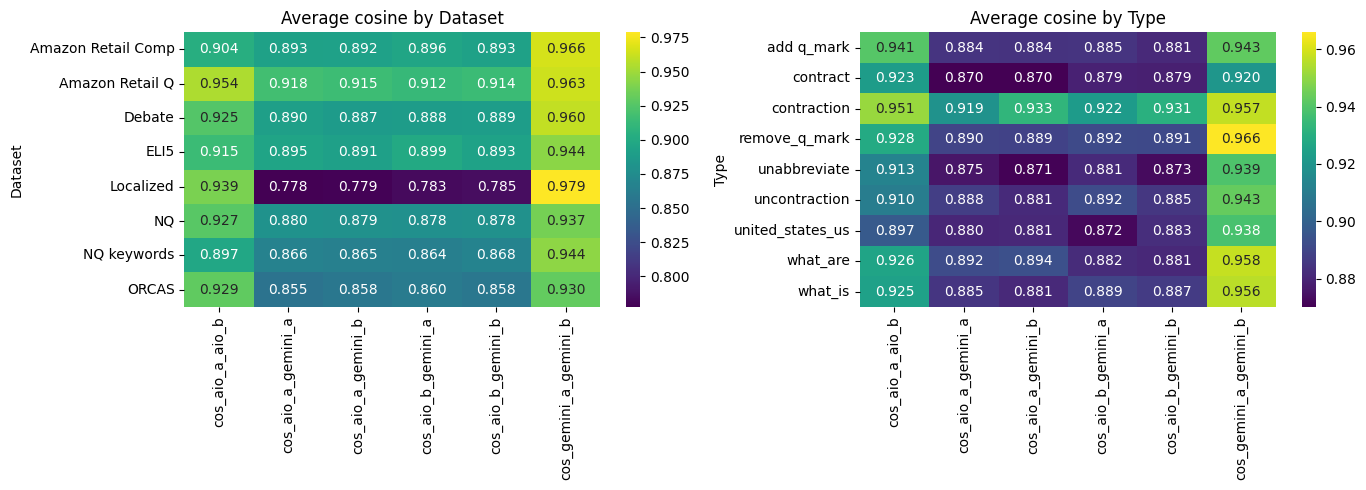

In [15]:
# Dataset/Type cosine summaries
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except Exception:
    sns = None

meta_path = Path("AIO_Benchmark_Dataset_Robust_Changes.csv")


meta = pd.read_csv(meta_path)
meta['ID'] = meta['ID'].astype(str)
meta['Modifier'] = meta['Modifier'].str.lower()
meta_a = meta[meta['Modifier'] == 'a'][['ID', 'Dataset', 'Type']]

merged = embed_df.copy()
merged['ID'] = merged['ID'].astype(str)
merged = merged.merge(meta_a, on='ID', how='left', validate='one_to_one')

missing_meta = merged['Dataset'].isna().sum()
print(f"Rows missing Dataset/Type mapping: {missing_meta}")

cos_cols = list(pairs.keys())

dataset_table = (
    merged.dropna(subset=['Dataset'])
    .groupby('Dataset')[cos_cols]
    .mean()
    .sort_index()
)

type_table = (
    merged.dropna(subset=['Type'])
    .groupby('Type')[cos_cols]
    .mean()
    .sort_index()
)

dataset_out = embed_output_path.with_name(embed_output_path.stem + "_dataset_cos.csv")
type_out = embed_output_path.with_name(embed_output_path.stem + "_type_cos.csv")

dataset_table.to_csv(dataset_out)
type_table.to_csv(type_out)

print("Dataset-level averages saved to", dataset_out)
print("Type-level averages saved to", type_out)
print("Dataset averages:", display(dataset_table))
print("Type averages:", display(type_table))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if sns:
    sns.heatmap(dataset_table, annot=True, fmt=".3f", cmap="viridis", ax=axes[0])
    axes[0].set_title("Average cosine by Dataset")
    sns.heatmap(type_table, annot=True, fmt=".3f", cmap="viridis", ax=axes[1])
    axes[1].set_title("Average cosine by Type")
else:
    for ax, table, title in zip(axes, [dataset_table, type_table], ["Average cosine by Dataset", "Average cosine by Type"]):
        im = ax.imshow(table.values, aspect='auto', cmap='viridis')
        ax.set_title(title)
        ax.set_xticks(range(len(table.columns)))
        ax.set_xticklabels(table.columns, rotation=45, ha='right')
        ax.set_yticks(range(len(table.index)))
        ax.set_yticklabels(table.index)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [16]:
# Jaccard similarity on word sets for each text pair
import re
import numpy as np
import pandas as pd
from pathlib import Path

text_path = output_path if "output_path" in globals() else Path("combined_ai_overview_gemini.csv")
text_df = pd.read_csv(text_path)


def _tokens(text):
    if not isinstance(text, str):
        return []
    return re.findall(r"\b\w+\b", text.lower())


def _word_set(text):
    return set(_tokens(text))


def _jaccard_words(t1, t2):
    s1, s2 = _word_set(t1), _word_set(t2)
    if not s1 and not s2:
        return np.nan
    return len(s1 & s2) / len(s1 | s2)


text_pairs = {
    "jaccard_aio_a_aio_b": ("aio_text_a", "aio_text_b"),
    "jaccard_aio_a_gemini_a": ("aio_text_a", "gemini_text_a"),
    "jaccard_aio_a_gemini_b": ("aio_text_a", "gemini_text_b"),
    "jaccard_aio_b_gemini_a": ("aio_text_b", "gemini_text_a"),
    "jaccard_aio_b_gemini_b": ("aio_text_b", "gemini_text_b"),
    "jaccard_gemini_a_gemini_b": ("gemini_text_a", "gemini_text_b"),
}

for out_col, (c1, c2) in text_pairs.items():
    text_df[out_col] = [
        _jaccard_words(r[c1], r[c2])
        for _, r in text_df[[c1, c2]].iterrows()
    ]

jaccard_cols = list(text_pairs.keys())
jaccard_avg = text_df[jaccard_cols].mean(numeric_only=True)
print("Average Jaccard similarities:")
for name, val in jaccard_avg.items():
    print(f"{name}: {val:.4f}")


Average Jaccard similarities:
jaccard_aio_a_aio_b: 0.4095
jaccard_aio_a_gemini_a: 0.2018
jaccard_aio_a_gemini_b: 0.2019
jaccard_aio_b_gemini_a: 0.2033
jaccard_aio_b_gemini_b: 0.2013
jaccard_gemini_a_gemini_b: 0.4223


In [17]:
# Absolute word-count differences for each pair and saved metrics

def _abs_word_len_diff(t1, t2):
    t1_tokens, t2_tokens = _tokens(t1), _tokens(t2)
    if not t1_tokens and not t2_tokens:
        return np.nan
    return abs(len(t1_tokens) - len(t2_tokens))


len_diff_pairs = {
    "abs_len_diff_aio_a_aio_b": ("aio_text_a", "aio_text_b"),
    "abs_len_diff_aio_a_gemini_a": ("aio_text_a", "gemini_text_a"),
    "abs_len_diff_aio_a_gemini_b": ("aio_text_a", "gemini_text_b"),
    "abs_len_diff_aio_b_gemini_a": ("aio_text_b", "gemini_text_a"),
    "abs_len_diff_aio_b_gemini_b": ("aio_text_b", "gemini_text_b"),
    "abs_len_diff_gemini_a_gemini_b": ("gemini_text_a", "gemini_text_b"),
}

for out_col, (c1, c2) in len_diff_pairs.items():
    text_df[out_col] = [
        _abs_word_len_diff(r[c1], r[c2])
        for _, r in text_df[[c1, c2]].iterrows()
    ]

len_diff_cols = list(len_diff_pairs.keys())
len_diff_avg = text_df[len_diff_cols].mean(numeric_only=True)
print("Average absolute word-count differences:")
for name, val in len_diff_avg.items():
    print(f"{name}: {val:.2f}")

text_metrics_cols = ["ID", *jaccard_cols, *len_diff_cols]
text_metrics_df = text_df[text_metrics_cols]

metrics_out = Path("combined_ai_overview_gemini_text_metrics.csv")
text_metrics_df.to_csv(metrics_out, index=False)
print(f"Saved text metrics to {metrics_out}")

if "embed_df" in globals():
    merged_metrics = embed_df.merge(text_metrics_df, on="ID", how="left")
    merged_out = embed_output_path.with_name(embed_output_path.stem + "_with_text_metrics.csv")
    merged_metrics.to_csv(merged_out, index=False)
    print(f"Saved embeddings + text metrics to {merged_out}")


Average absolute word-count differences:
abs_len_diff_aio_a_aio_b: 21.56
abs_len_diff_aio_a_gemini_a: 287.87
abs_len_diff_aio_a_gemini_b: 286.20
abs_len_diff_aio_b_gemini_a: 288.63
abs_len_diff_aio_b_gemini_b: 286.88
abs_len_diff_gemini_a_gemini_b: 66.26
Saved text metrics to combined_ai_overview_gemini_text_metrics.csv
Saved embeddings + text metrics to combined_ai_overview_gemini_embed_with_text_metrics.csv


In [ ]:
# RBO vs cosine similarity correlation tables
import pandas as pd
import numpy as np
from pathlib import Path

rbo_path = Path("AIO_Gemini_robust_to_changes_w_rbo.csv")
cos_path = Path("combined_ai_overview_gemini_embed_cos_sim.csv")

rbo_cols = [
    "rbo_gem_l",
    "rbo_gem_d",
    "rbo_aio_l",
    "rbo_aio_d",
    "rbo_serp_l",
    "rbo_serp_d",
]

cos_cols = [
    "cos_aio_a_aio_b",
    "cos_aio_a_gemini_a",
    "cos_aio_a_gemini_b",
    "cos_aio_b_gemini_a",
    "cos_aio_b_gemini_b",
    "cos_gemini_a_gemini_b",
]

rbo_df = pd.read_csv(rbo_path)
rbo_df["base_id"] = rbo_df["ID"].str.replace(r"[ab]$", "", regex=True)
rbo_df[rbo_cols] = rbo_df[rbo_cols].apply(pd.to_numeric, errors="coerce")

cos_df = pd.read_csv(cos_path)
cos_df["base_id"] = cos_df["ID"].astype(str)

merged = (
    rbo_df.dropna(subset=rbo_cols, how="all")
    .merge(
        cos_df[["ID", "base_id", *cos_cols]],
        on="base_id",
        how="inner",
        suffixes=("_rbo", "_cos"),
    )
)

print(f"Merged rows with RBO + cosine data: {len(merged)}")

pearson_corr = merged[rbo_cols + cos_cols].corr(method="pearson").loc[rbo_cols, cos_cols]
spearman_corr = merged[rbo_cols + cos_cols].corr(method="spearman").loc[rbo_cols, cos_cols]

corr_out = Path("rbo_cosine_correlation_pearson.csv")
pearson_corr.to_csv(corr_out)
print(f"Saved Pearson correlations to {corr_out}")

corr_out_s = Path("rbo_cosine_correlation_spearman.csv")
spearman_corr.to_csv(corr_out_s)
print(f"Saved Spearman correlations to {corr_out_s}")

print("Pearson correlations (RBO rows, cosine cols):")
display(pearson_corr)
print("Spearman correlations (RBO rows, cosine cols):")
display(spearman_corr)



Merged rows with RBO + cosine data: 188
Saved Pearson correlations to rbo_cosine_correlation_pearson.csv
Saved Spearman correlations to rbo_cosine_correlation_spearman.csv
Pearson correlations (RBO rows, cosine cols):


,cos_aio_a_aio_b,cos_aio_a_gemini_a,cos_aio_a_gemini_b,cos_aio_b_gemini_a,cos_aio_b_gemini_b,cos_gemini_a_gemini_b
rbo_gem_l,0.140668,0.026779,0.058320,0.009861,-0.002170,0.257980
rbo_gem_d,0.194406,0.046050,0.080348,0.027093,0.003220,0.287227
rbo_aio_l,0.484354,0.013589,-0.007802,0.002622,-0.006592,0.048220
rbo_aio_d,0.441423,0.030421,0.013756,0.019372,0.008789,0.067731
rbo_serp_l,0.205520,-0.032919,-0.053752,-0.052888,-0.052558,0.034818
rbo_serp_d,0.191364,0.006730,0.012206,-0.035563,0.027948,0.071563


Spearman correlations (RBO rows, cosine cols):


,cos_aio_a_aio_b,cos_aio_a_gemini_a,cos_aio_a_gemini_b,cos_aio_b_gemini_a,cos_aio_b_gemini_b,cos_gemini_a_gemini_b
rbo_gem_l,0.117423,-0.074259,-0.013376,-0.029868,-0.030065,0.269207
rbo_gem_d,0.171471,-0.053289,0.011534,-0.017199,-0.029698,0.288666
rbo_aio_l,0.467273,0.028140,0.000276,-0.004161,-0.001327,0.026750
rbo_aio_d,0.439224,0.048809,0.028376,0.018203,0.025919,0.024012
rbo_serp_l,0.184119,-0.125130,-0.108608,-0.104017,-0.068437,-0.016453
rbo_serp_d,0.184640,-0.070796,-0.048776,-0.068795,0.005930,0.053429


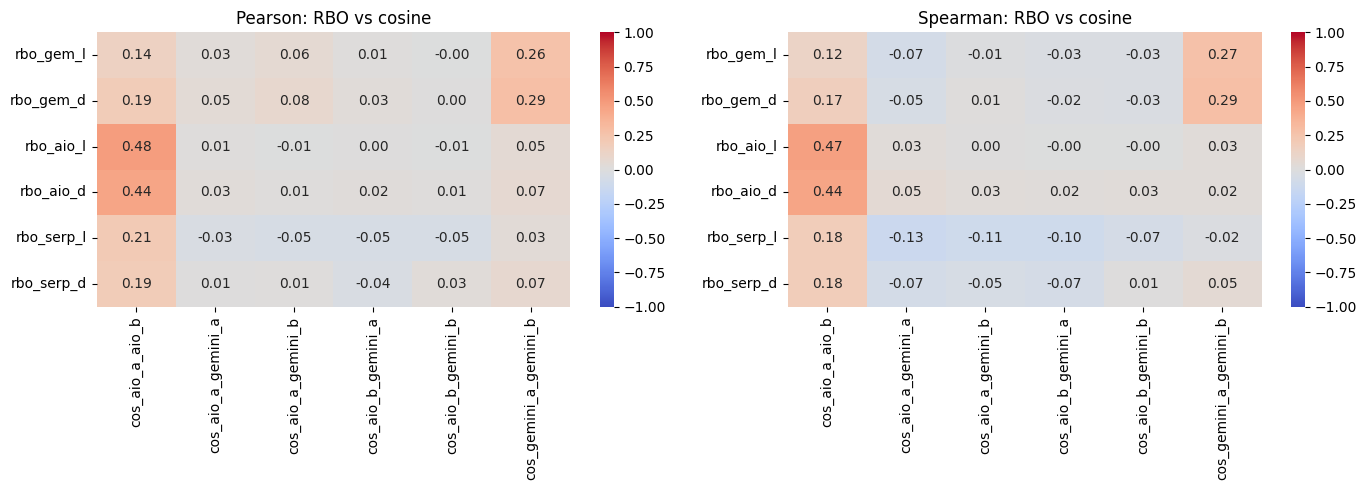

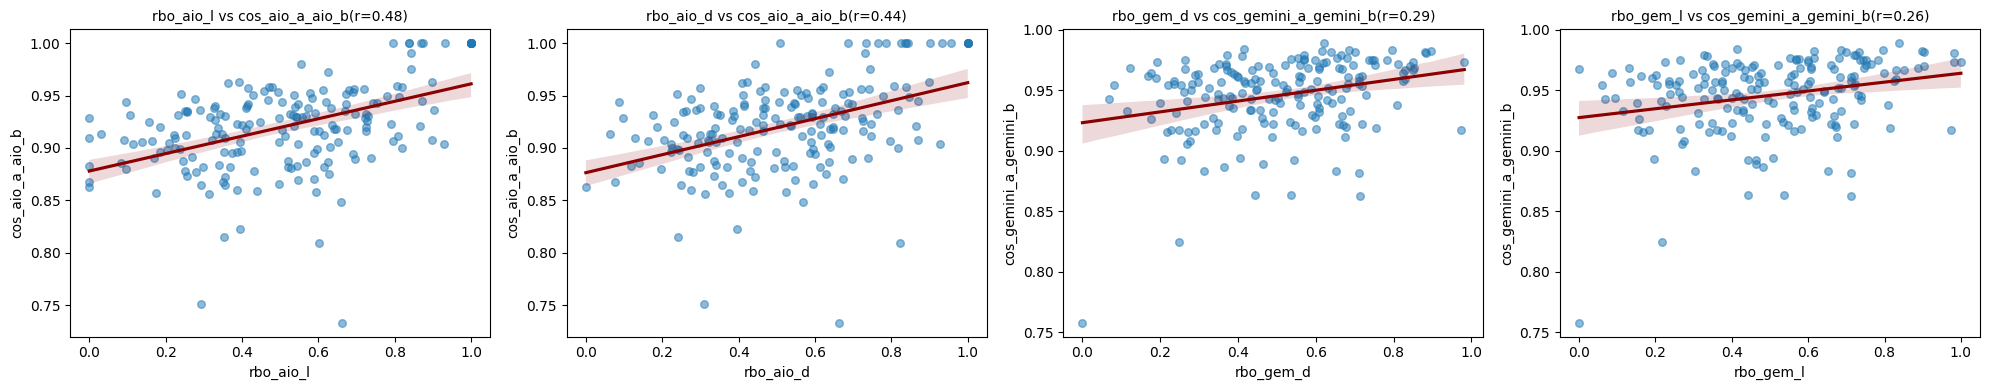

In [20]:
# Visualizing RBO vs cosine similarity
import numpy as np
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except Exception:
    sns = None

if "merged" not in globals():
    raise RuntimeError("Run the correlation cell first to build merged and correlation tables.")

# Heatmaps of correlation matrices
if sns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0])
    axes[0].set_title("Pearson: RBO vs cosine")
    sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
    axes[1].set_title("Spearman: RBO vs cosine")
    plt.tight_layout()
    plt.show()
else:
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(pearson_corr, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(pearson_corr.columns)))
    ax.set_xticklabels(pearson_corr.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(pearson_corr.index)))
    ax.set_yticklabels(pearson_corr.index)
    ax.set_title("Pearson: RBO vs cosine")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

# Scatter/regression for strongest pairs
corr_long = pearson_corr.stack().reset_index(name="corr")
corr_long["abs_corr"] = corr_long["corr"].abs()
top_pairs = corr_long.sort_values("abs_corr", ascending=False).head(4)

if top_pairs.empty:
    raise RuntimeError("No correlation pairs available for plotting.")

fig, axes = plt.subplots(1, len(top_pairs), figsize=(5 * len(top_pairs), 4), sharey=False)
if not isinstance(axes, (list, tuple, np.ndarray)):
    axes = [axes]

for ax, (_, row) in zip(axes, top_pairs.iterrows()):
    rbo_col = row["level_0"]
    cos_col = row["level_1"]
    if sns:
        sns.regplot(data=merged, x=rbo_col, y=cos_col, ax=ax, scatter_kws={"alpha": 0.5, "s": 30}, line_kws={"color": "darkred"})
    else:
        ax.scatter(merged[rbo_col], merged[cos_col], alpha=0.5, s=30)
    ax.set_title(f"{rbo_col} vs {cos_col}(r={row['corr']:.2f})", fontsize=10)
    ax.set_xlabel(rbo_col)
    ax.set_ylabel(cos_col)

plt.tight_layout()
plt.show()


In [2]:
# RBO vs Jaccard similarity correlation tables
import pandas as pd
from pathlib import Path

rbo_path = Path("AIO_Gemini_robust_to_changes_w_rbo.csv")
jaccard_path = Path("combined_ai_overview_gemini_text_metrics.csv")

rbo_cols = [
    "rbo_gem_l",
    "rbo_gem_d",
    "rbo_aio_l",
    "rbo_aio_d",
    "rbo_serp_l",
    "rbo_serp_d",
]

jaccard_cols = [
    "jaccard_aio_a_aio_b",
    "jaccard_aio_a_gemini_a",
    "jaccard_aio_a_gemini_b",
    "jaccard_aio_b_gemini_a",
    "jaccard_aio_b_gemini_b",
    "jaccard_gemini_a_gemini_b",
]

rbo_df = pd.read_csv(rbo_path)
rbo_df["base_id"] = rbo_df["ID"].str.replace(r"[ab]$", "", regex=True)
rbo_df[rbo_cols] = rbo_df[rbo_cols].apply(pd.to_numeric, errors="coerce")

jaccard_df = pd.read_csv(jaccard_path)
jaccard_df["base_id"] = jaccard_df["ID"].astype(str)
jaccard_df[jaccard_cols] = jaccard_df[jaccard_cols].apply(pd.to_numeric, errors="coerce")

merged_jaccard = (
    rbo_df.dropna(subset=rbo_cols, how="all")
    .merge(
        jaccard_df[["ID", "base_id", *jaccard_cols]],
        on="base_id",
        how="inner",
        suffixes=("_rbo", "_jaccard"),
    )
)

print(f"Merged rows with RBO + Jaccard data: {len(merged_jaccard)}")

pearson_corr_jaccard = merged_jaccard[rbo_cols + jaccard_cols].corr(method="pearson").loc[rbo_cols, jaccard_cols]
spearman_corr_jaccard = merged_jaccard[rbo_cols + jaccard_cols].corr(method="spearman").loc[rbo_cols, jaccard_cols]

corr_out_jaccard = Path("rbo_jaccard_correlation_pearson.csv")
pearson_corr_jaccard.to_csv(corr_out_jaccard)
print(f"Saved Pearson correlations to {corr_out_jaccard}")

corr_out_jaccard_s = Path("rbo_jaccard_correlation_spearman.csv")
spearman_corr_jaccard.to_csv(corr_out_jaccard_s)
print(f"Saved Spearman correlations to {corr_out_jaccard_s}")

print("Pearson correlations (RBO rows, Jaccard cols):")
display(pearson_corr_jaccard)
print("Spearman correlations (RBO rows, Jaccard cols):")
display(spearman_corr_jaccard)


Merged rows with RBO + Jaccard data: 188
Saved Pearson correlations to rbo_jaccard_correlation_pearson.csv
Saved Spearman correlations to rbo_jaccard_correlation_spearman.csv
Pearson correlations (RBO rows, Jaccard cols):


,jaccard_aio_a_aio_b,jaccard_aio_a_gemini_a,jaccard_aio_a_gemini_b,jaccard_aio_b_gemini_a,jaccard_aio_b_gemini_b,jaccard_gemini_a_gemini_b
rbo_gem_l,0.271146,0.231931,0.214382,0.240882,0.193613,0.550007
rbo_gem_d,0.293629,0.202356,0.192574,0.213141,0.153469,0.518117
rbo_aio_l,0.626688,0.220696,0.215962,0.231180,0.198021,0.196732
rbo_aio_d,0.549005,0.156231,0.156263,0.178683,0.141889,0.150728
rbo_serp_l,0.320151,0.223243,0.226498,0.215628,0.200538,0.193327
rbo_serp_d,0.224817,0.029207,0.028657,0.032161,0.029341,0.088577


Spearman correlations (RBO rows, Jaccard cols):


,jaccard_aio_a_aio_b,jaccard_aio_a_gemini_a,jaccard_aio_a_gemini_b,jaccard_aio_b_gemini_a,jaccard_aio_b_gemini_b,jaccard_gemini_a_gemini_b
rbo_gem_l,0.298182,0.157925,0.178716,0.187152,0.171916,0.549288
rbo_gem_d,0.319681,0.143021,0.165551,0.175632,0.163821,0.520399
rbo_aio_l,0.524681,0.205790,0.188111,0.168055,0.147684,0.193951
rbo_aio_d,0.460056,0.164579,0.150636,0.142931,0.124829,0.141863
rbo_serp_l,0.323969,0.196006,0.194946,0.156952,0.174094,0.172439
rbo_serp_d,0.204156,-0.009031,-0.002830,-0.012024,0.015338,0.056316


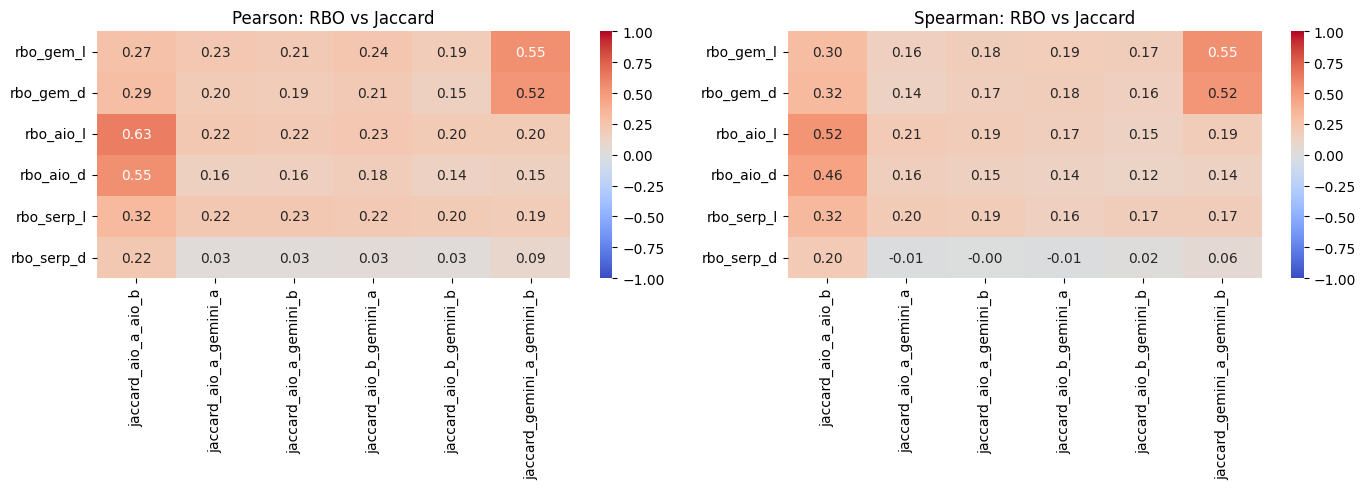

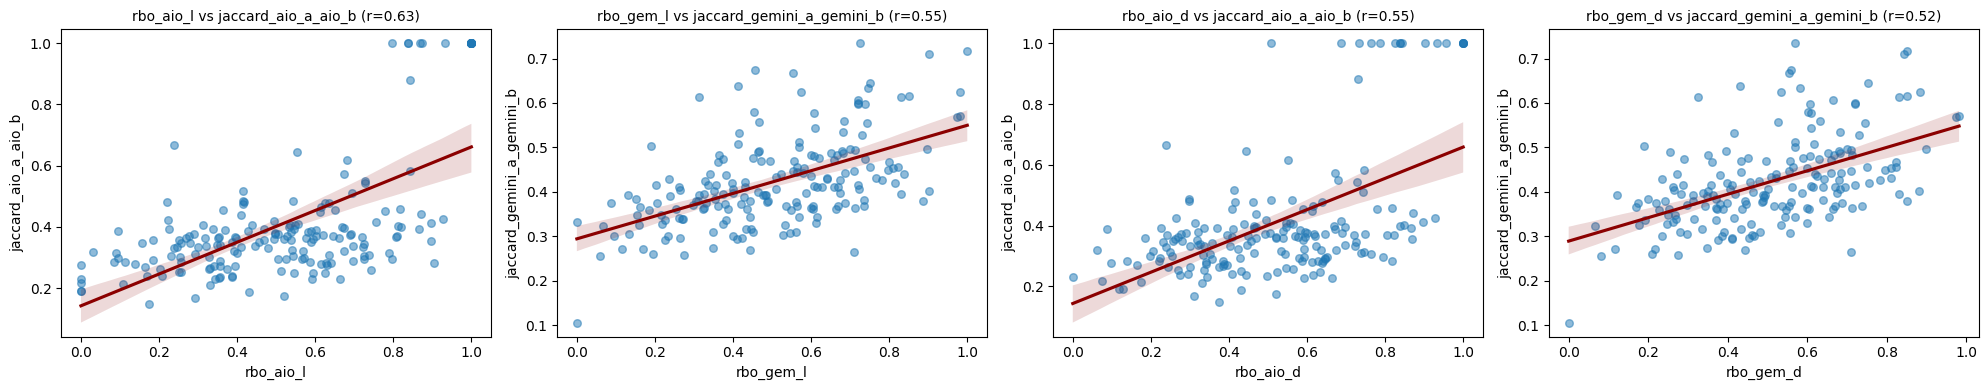

In [3]:
# Visualizing RBO vs Jaccard similarity
import numpy as np
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except Exception:
    sns = None

if "merged_jaccard" not in globals():
    raise RuntimeError("Run the RBO vs Jaccard correlation cell first.")

# Heatmaps of correlation matrices
if sns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(pearson_corr_jaccard, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0])
    axes[0].set_title("Pearson: RBO vs Jaccard")
    sns.heatmap(spearman_corr_jaccard, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
    axes[1].set_title("Spearman: RBO vs Jaccard")
    plt.tight_layout()
    plt.show()
else:
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(pearson_corr_jaccard, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(pearson_corr_jaccard.columns)))
    ax.set_xticklabels(pearson_corr_jaccard.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(pearson_corr_jaccard.index)))
    ax.set_yticklabels(pearson_corr_jaccard.index)
    ax.set_title("Pearson: RBO vs Jaccard")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

# Scatter/regression for strongest pairs
corr_long_jaccard = pearson_corr_jaccard.stack().reset_index(name="corr")
corr_long_jaccard["abs_corr"] = corr_long_jaccard["corr"].abs()
top_pairs_jaccard = corr_long_jaccard.sort_values("abs_corr", ascending=False).head(4)

if top_pairs_jaccard.empty:
    raise RuntimeError("No correlation pairs available for plotting.")

fig, axes = plt.subplots(1, len(top_pairs_jaccard), figsize=(5 * len(top_pairs_jaccard), 4), sharey=False)
if not isinstance(axes, (list, tuple, np.ndarray)):
    axes = [axes]

for ax, (_, row) in zip(axes, top_pairs_jaccard.iterrows()):
    rbo_col = row["level_0"]
    jaccard_col = row["level_1"]
    if sns:
        sns.regplot(data=merged_jaccard, x=rbo_col, y=jaccard_col, ax=ax, scatter_kws={"alpha": 0.5, "s": 30}, line_kws={"color": "darkred"})
    else:
        ax.scatter(merged_jaccard[rbo_col], merged_jaccard[jaccard_col], alpha=0.5, s=30)
    ax.set_title(f"{rbo_col} vs {jaccard_col} (r={row['corr']:.2f})", fontsize=10)
    ax.set_xlabel(rbo_col)
    ax.set_ylabel(jaccard_col)

plt.tight_layout()
plt.show()
